In [ ]:
import pandas as pd

In [ ]:
sales= pd.read_csv("/content/drive/MyDrive/train.csv")
sales

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,1,2013-01-01,1,BABY CARE,0.000,0
2,2,2013-01-01,1,BEAUTY,0.000,0
3,3,2013-01-01,1,BEVERAGES,0.000,0
4,4,2013-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


In [ ]:
sales.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [ ]:
sales.tail()


,id,date,store_nbr,family,sales,onpromotion
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8
3000887,3000887,2017-08-15,9,SEAFOOD,16.000,0


In [ ]:
sales.sample(14)

,id,date,store_nbr,family,sales,onpromotion
2965634,2965634,2017-07-27,2,MAGAZINES,4.000,0
2826357,2826357,2017-05-10,12,CELEBRATION,17.000,0
2382277,2382277,2016-09-01,51,CLEANING,1208.000,12
679925,679925,2014-01-18,36,PET SUPPLIES,3.000,0
1430252,1430252,2015-03-16,39,SEAFOOD,8.117,0
2640108,2640108,2017-01-25,36,DELI,177.625,7
1810182,1810182,2015-10-15,5,AUTOMOTIVE,4.000,0
2695556,2695556,2017-02-25,41,HOME APPLIANCES,2.000,0
30633,30633,2013-01-18,19,DELI,92.000,0
152344,152344,2013-03-27,33,HOME AND KITCHEN II,0.000,0


In [ ]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [ ]:
sales.isna().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0


In [ ]:
sales.dtypes

,0
id,int64
date,object
store_nbr,int64
family,object
sales,float64
onpromotion,int64


In [ ]:
sales['date'] = pd.to_datetime(sales['date'])

In [ ]:
sales.dtypes

,0
id,int64
date,datetime64[ns]
store_nbr,int64
family,object
sales,float64
onpromotion,int64


In [ ]:
sales.describe()

,id,date,store_nbr,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2015-04-24 08:27:04.703088384,2.750000e+01,3.577757e+02,2.602770e+00
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02
std,8.662819e+05,NaN,1.558579e+01,1.101998e+03,1.221888e+01


In [ ]:
sales.isna().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0


In [ ]:
sales.duplicated().sum()

np.int64(0)

In [ ]:
sales[sales['sales']==0].shape

(939130, 6)

In [ ]:
sales[sales['sales']==0].groupby('date').size()

,0
date,
2013-01-01,1765
2013-01-02,918
2013-01-03,931
2013-01-04,923
2013-01-05,905
...,...
2017-08-11,249
2017-08-12,249
2017-08-13,245


In [ ]:
zero_sales = (sales['sales']==0).mean()*100
zero_sales

np.float64(31.29506999261552)

In [ ]:
sales[sales.sales==0].groupby('store_nbr').size()

,0
store_nbr,
1,12799
2,12002
3,10081
4,12630
5,12414
6,12620
7,11577
8,11076
9,12196


In [ ]:
sales[sales.sales==0].groupby('family').size()

,0
family,
AUTOMOTIVE,11626
BABY CARE,85599
BEAUTY,23900
BEVERAGES,7331
BOOKS,88167
BREAD/BAKERY,7330
CELEBRATION,39679
CLEANING,7331
DAIRY,7331


In [ ]:
zero_store_rate = (
    sales[sales.sales == 0]
    .groupby('store_nbr')
    .size()
    /
    sales.groupby('store_nbr').size()
    *100
)

zero_store_rate.sort_values(ascending=False)

,0
store_nbr,
52,93.539912
22,68.548910
42,62.216584
21,61.300655
29,57.217664
20,54.471676
53,43.237602
32,39.579285
35,39.116821


In [ ]:
zero_family_rate = (
    sales[sales.sales == 0]
    .groupby('family')
    .size()
    /
    sales.groupby('family').size()
    *100
)

zero_family_rate.sort_values(ascending=False)

,0
family,
BOOKS,96.955001
BABY CARE,94.131037
SCHOOL AND OFFICE SUPPLIES,74.082871
HOME APPLIANCES,73.517639
LADIESWEAR,59.846485
MAGAZINES,56.538665
PET SUPPLIES,54.615334
HARDWARE,47.862233
LAWN AND GARDEN,46.784552


In [ ]:
sales['year'] = sales['date'].dt.year
sales['month'] = sales['date'].dt.month
sales['day'] = sales['date'].dt.day

print(sales[['date', 'year', 'month', 'day']].sample(12))

              date  year  month  day
539894  2013-10-30  2013     10   30
864961  2014-05-02  2014      5    2
19279   2013-01-11  2013      1   11
2289720 2016-07-11  2016      7   11
2351884 2016-08-15  2016      8   15
2886099 2017-06-12  2017      6   12
321966  2013-06-30  2013      6   30
594214  2013-11-30  2013     11   30
212698  2013-04-30  2013      4   30
2377476 2016-08-30  2016      8   30
1320693 2015-01-14  2015      1   14
2826965 2017-05-10  2017      5   10


In [ ]:
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt


<Axes: ylabel='sales'>

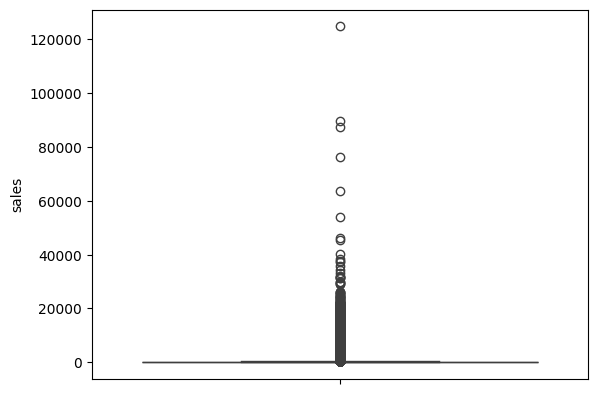

In [ ]:
sns.boxplot(sales['sales'])

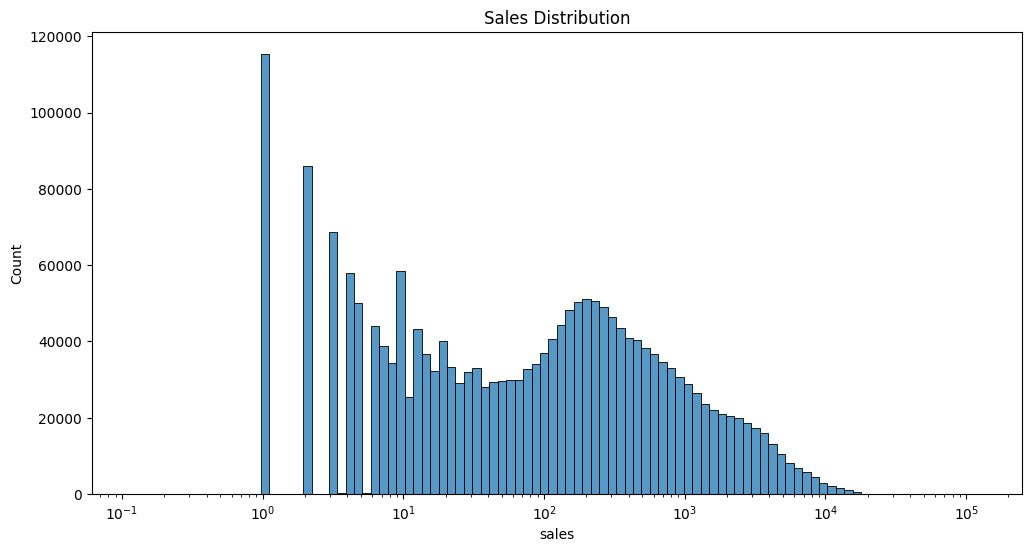

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(
    data=sales,
    x='sales',
    bins=100,
    log_scale=True)
plt.title('Sales Distribution')
plt.show()

In [ ]:
sales.sort_values('sales',ascending=False).head(10)

,id,date,store_nbr,family,sales,onpromotion,year,month,day
2163723,2163723,2016-05-02,2,GROCERY I,124717.000,59,2016,5,2
2445984,2445984,2016-10-07,39,MEATS,89576.360,0,2016,10,7
2144154,2144154,2016-04-21,20,GROCERY I,87438.516,53,2016,4,21
2139699,2139699,2016-04-18,45,GROCERY I,76090.000,38,2016,4,18
2153031,2153031,2016-04-26,2,GROCERY I,63434.000,30,2016,4,26
2145045,2145045,2016-04-21,45,GROCERY I,53874.000,44,2016,4,21
562596,562596,2013-11-12,44,GROCERY I,46271.000,0,2013,11,12
1257246,1257246,2014-12-08,35,GROCERY I,45361.000,3,2014,12,8
1916586,1916586,2015-12-14,35,GROCERY I,40351.460,7,2015,12,14
2760297,2760297,2017-04-02,9,GROCERY I,38422.625,73,2017,4,2


In [ ]:
# Data Stores

In [ ]:
stores=pd.read_csv("/content/drive/MyDrive/stores.csv")
stores.head(12)

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4
5,6,Quito,Pichincha,D,13
6,7,Quito,Pichincha,D,8
7,8,Quito,Pichincha,D,8
8,9,Quito,Pichincha,B,6
9,10,Quito,Pichincha,C,15


In [ ]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


In [ ]:
stores.isnull().sum()

,0
store_nbr,0
city,0
state,0
type,0
cluster,0


In [ ]:
stores.duplicated().sum()

np.int64(0)

In [ ]:
stores.describe()

,store_nbr,cluster
count,54.000000,54.000000
mean,27.500000,8.481481
std,15.732133,4.693395
min,1.000000,1.000000
25%,14.250000,4.000000
50%,27.500000,8.500000
75%,40.750000,13.000000
max,54.000000,17.000000


In [ ]:
# Data  Transactions

In [ ]:
transactions=pd.read_csv("/content/drive/MyDrive/transactions.csv")
transactions.head(12)

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922
5,2013-01-02,5,1903
6,2013-01-02,6,2143
7,2013-01-02,7,1874
8,2013-01-02,8,3250
9,2013-01-02,9,2940


In [ ]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          83488 non-null  object
 1   store_nbr     83488 non-null  int64 
 2   transactions  83488 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.9+ MB


In [ ]:
transactions['date'] = pd.to_datetime(transactions['date'])

In [ ]:
transactions.dtypes

,0
date,datetime64[ns]
store_nbr,int64
transactions,int64


In [ ]:
transactions.isnull().sum()

,0
date,0
store_nbr,0
transactions,0


In [ ]:
transactions.duplicated().sum()


np.int64(0)

In [ ]:
transactions.describe()

,date,store_nbr,transactions
count,83488,83488.000000,83488.000000
mean,2015-05-20 16:07:40.866232064,26.939237,1694.602158
min,2013-01-01 00:00:00,1.000000,5.000000
25%,2014-03-27 00:00:00,13.000000,1046.000000
50%,2015-06-08 00:00:00,27.000000,1393.000000
75%,2016-07-14 06:00:00,40.000000,2079.000000
max,2017-08-15 00:00:00,54.000000,8359.000000
std,NaN,15.608204,963.286644


In [ ]:
# Data Holidays

In [ ]:
holidays=pd.read_csv("/content/drive/MyDrive/holidays_events.csv")
holidays.head(12)

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
5,2012-05-12,Holiday,Local,Puyo,Cantonizacion del Puyo,False
6,2012-06-23,Holiday,Local,Guaranda,Cantonizacion de Guaranda,False
7,2012-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
8,2012-06-25,Holiday,Local,Latacunga,Cantonizacion de Latacunga,False
9,2012-06-25,Holiday,Local,Machala,Fundacion de Machala,False


In [ ]:
holidays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         350 non-null    object
 1   type         350 non-null    object
 2   locale       350 non-null    object
 3   locale_name  350 non-null    object
 4   description  350 non-null    object
 5   transferred  350 non-null    bool  
dtypes: bool(1), object(5)
memory usage: 14.1+ KB


In [ ]:
holidays['date'] = pd.to_datetime(holidays['date'])

In [ ]:
holidays.dtypes

,0
date,datetime64[ns]
type,object
locale,object
locale_name,object
description,object
transferred,bool


In [ ]:
holidays.isnull().sum()

,0
date,0
type,0
locale,0
locale_name,0
description,0
transferred,0


In [ ]:
holidays.duplicated().sum()


np.int64(0)

In [ ]:
holidays['type'].value_counts()

,count
type,
Holiday,221
Event,56
Additional,51
Transfer,12
Bridge,5
Work Day,5


In [ ]:
holidays['locale'].value_counts()

,count
locale,
National,174
Local,152
Regional,24


In [ ]:
holidays['transferred'].value_counts()

,count
transferred,
False,338
True,12


In [ ]:
holidays['locale_name'].nunique()

24

In [ ]:
# Merge Data

In [ ]:

stores = stores.rename(columns={'type':'store_type'})
holidays = holidays.rename(columns={'type':'holiday_type'})


In [ ]:
# 1 Merge Sales + Stores

df = sales.merge(stores, on='store_nbr', how='left', validate='many_to_one')
print("After stores merge:", df.shape)


# 2 Merge Transactions

df = df.merge(transactions, on=['date','store_nbr'], how='left', validate='many_to_one')
print("After transactions merge:", df.shape)
safe_holidays = (holidays.drop_duplicates(subset=['date']))

# 3 Merge Holidays

df = df.merge(safe_holidays, on='date', how='left', validate='many_to_one')
print("After holidays merge:", df.shape)

After stores merge: (3000888, 13)
After transactions merge: (3000888, 14)
After holidays merge: (3000888, 19)


In [ ]:

print("Original sales rows:", len(sales))
print("Final dataframe rows:", len(df))
print("Duplicates:", df.duplicated().sum())


Original sales rows: 3000888
Final dataframe rows: 3000888
Duplicates: 0


In [ ]:
df.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0
year,0
month,0
day,0
city,0


In [ ]:
df['transactions'] = df['transactions'].fillna(0)

df['holiday_type'] = df['holiday_type'].fillna('Regular Day')

df['locale'] = df['locale'].fillna('No Holiday')

df['locale_name'] = df['locale_name'].fillna('No Holiday')

df['description'] = df['description'].fillna('No Holiday')

df['transferred'] = df['transferred'].fillna(False)

/tmp/ipykernel_2905/374970687.py:11: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [ ]:
df.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0
year,0
month,0
day,0
city,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 19 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        object        
 4   sales         float64       
 5   onpromotion   int64         
 6   year          int32         
 7   month         int32         
 8   day           int32         
 9   city          object        
 10  state         object        
 11  store_type    object        
 12  cluster       int64         
 13  transactions  float64       
 14  holiday_type  object        
 15  locale        object        
 16  locale_name   object        
 17  description   object        
 18  transferred   bool          
dtypes: bool(1), datetime64[ns](1), float64(2), int32(3), int64(4), object(8)
memory usage: 380.6+ MB


In [ ]:
df['transactions'] = df['transactions'].astype('int64')

In [ ]:
df.dtypes

,0
id,int64
date,datetime64[ns]
store_nbr,int64
family,object
sales,float64
onpromotion,int64
year,int32
month,int32
day,int32
city,object


In [ ]:
df.sample(12)

,id,date,store_nbr,family,sales,onpromotion,year,month,day,city,state,store_type,cluster,transactions,holiday_type,locale,locale_name,description,transferred
1355577,1355577,2015-02-02,44,BEVERAGES,4433.0,2,2015,2,2,Quito,Pichincha,A,5,3927,Regular Day,No Holiday,No Holiday,No Holiday,False
563904,563904,2013-11-13,31,AUTOMOTIVE,5.0,0,2013,11,13,Babahoyo,Los Rios,B,10,1012,Regular Day,No Holiday,No Holiday,No Holiday,False
1549635,1549635,2015-05-22,39,LINGERIE,6.0,0,2015,5,22,Cuenca,Azuay,B,6,1227,Regular Day,No Holiday,No Holiday,No Holiday,False
1424316,1424316,2015-03-13,23,BEVERAGES,588.0,0,2015,3,13,Ambato,Tungurahua,D,9,1019,Regular Day,No Holiday,No Holiday,No Holiday,False
2412871,2412871,2016-09-19,10,EGGS,139.0,10,2016,9,19,Quito,Pichincha,C,15,844,Regular Day,No Holiday,No Holiday,No Holiday,False
1460108,1460108,2015-04-02,27,MAGAZINES,1.0,0,2015,4,2,Daule,Guayas,D,1,1421,Regular Day,No Holiday,No Holiday,No Holiday,False
581691,581691,2013-11-23,30,AUTOMOTIVE,1.0,0,2013,11,23,Guayaquil,Guayas,C,3,732,Regular Day,No Holiday,No Holiday,No Holiday,False
2210187,2210187,2016-05-28,23,GROCERY I,2302.0,61,2016,5,28,Ambato,Tungurahua,D,9,1021,Regular Day,No Holiday,No Holiday,No Holiday,False
2788086,2788086,2017-04-18,38,HOME AND KITCHEN I,22.0,3,2017,4,18,Loja,Loja,D,4,1239,Regular Day,No Holiday,No Holiday,No Holiday,False
2561368,2561368,2016-12-11,27,CLEANING,1285.0,30,2016,12,11,Daule,Guayas,D,1,1971,Regular Day,No Holiday,No Holiday,No Holiday,False


In [ ]:
df.describe()

,id,date,store_nbr,sales,onpromotion,year,month,day,cluster,transactions
count,3.000888e+06,3000888,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2015-04-24 08:27:04.703088384,2.750000e+01,3.577757e+02,2.602770e+00,2.014838e+03,6.207838e+00,1.563005e+01,8.481481e+00,1.555808e+03
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00,2.013000e+03,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00,2.014000e+03,3.000000e+00,8.000000e+00,4.000000e+00,9.300000e+02
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00,2.015000e+03,6.000000e+00,1.600000e+01,8.500000e+00,1.331000e+03
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00,2.016000e+03,9.000000e+00,2.300000e+01,1.300000e+01,1.976250e+03
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02,2.017000e+03,1.200000e+01,3.100000e+01,1.700000e+01,8.359000e+03
std,8.662819e+05,NaN,1.558579e+01,1.101998e+03,1.221888e+01,1.345518e+00,3.385668e+00,8.794789e+00,4.649735e+00,1.033367e+03


In [ ]:
validation = df.groupby('holiday_type').agg(
    total_records=('sales','count'),
    zero_sales=('sales', lambda x: (x==0).sum()),
    zero_percentage=('sales', lambda x: round((x==0).mean()*100,2)),
    avg_sales=('sales','mean'),
    median_sales=('sales','median')
).reset_index()

validation.sort_values('zero_percentage', ascending=False)

,holiday_type,total_records,zero_sales,zero_percentage,avg_sales,median_sales
6,Work Day,7128,3009,42.21,334.753194,5.0
3,Holiday,270864,90060,33.25,352.430015,9.0
4,Regular Day,2551824,802871,31.46,352.159181,11.0
1,Bridge,5346,1504,28.13,446.750854,16.0
0,Additional,64152,17511,27.30,485.410252,18.0
2,Event,87318,21292,24.38,423.368077,16.0
5,Transfer,14256,2883,20.22,466.747805,24.0


In [ ]:
zero_by_store = (
    df.groupby('store_nbr')['sales']
      .apply(lambda x: (x==0).mean()*100)
      .sort_values(ascending=False))
print(zero_by_store.head(20))

store_nbr
52    93.539912
22    68.548910
42    62.216584
21    61.300655
29    57.217664
20    54.471676
53    43.237602
32    39.579285
35    39.116821
54    34.747715
36    34.695530
14    34.673937
16    34.529979
43    34.355431
30    33.936155
12    33.831786
33    33.174980
10    33.158785
13    33.156986
18    31.836176
Name: sales, dtype: float64


In [ ]:
zero_by_family = (
    df.groupby('family')['sales']
      .apply(lambda x: (x==0).mean()*100)
      .sort_values(ascending=False))
print(zero_by_family)


family
BOOKS                         96.955001
BABY CARE                     94.131037
SCHOOL AND OFFICE SUPPLIES    74.082871
HOME APPLIANCES               73.517639
LADIESWEAR                    59.846485
MAGAZINES                     56.538665
PET SUPPLIES                  54.615334
HARDWARE                      47.862233
LAWN AND GARDEN               46.784552
PLAYERS AND ELECTRONICS       44.886514
CELEBRATION                   43.633984
HOME CARE                     40.908991
HOME AND KITCHEN II           34.713425
HOME AND KITCHEN I            34.645245
PRODUCE                       28.355107
BEAUTY                        26.282220
SEAFOOD                       19.358670
LIQUOR,WINE,BEER              17.865312
LINGERIE                      16.046450
AUTOMOTIVE                    12.784816
GROCERY II                    12.112915
FROZEN FOODS                   8.091405
PREPARED FOODS                 8.083707
POULTRY                        8.076010
PERSONAL CARE                  8.

Zero sales observations were investigated across holiday types, stores, and product categories. The analysis showed that zero sales are not primarily driven by holidays, as holiday and regular days exhibit similar zero-sale rates. Instead, the occurrence of zero sales is strongly associated with product category characteristics. Low-demand categories such as Books and Baby Care show substantially higher proportions of zero-sales records, while essential categories such as Grocery, Dairy, and Beverages maintain consistently low zero-sale rates. Therefore, zero sales were considered valid business observations rather than data quality issues and were retained for subsequent analysis.


In [ ]:
#KPI (key performance indicator)

In [ ]:
sales_year = (df.groupby("year")["sales"].sum().reset_index())
sales_year

,year,sales
0,2013,1.404190e+08
1,2014,2.094742e+08
2,2015,2.408801e+08
3,2016,2.886545e+08
4,2017,1.942171e+08


In [ ]:
import plotly.express as px

fig = px.bar(
    sales_year,
    x="year",
    y="sales",
    title="Annual Revenue")

fig.show()

In [ ]:
sales_year["growth_%"] = (sales_year["sales"].pct_change()*100)
sales_year

,year,sales,growth_%
0,2013,1.404190e+08,NaN
1,2014,2.094742e+08,49.177978
2,2015,2.408801e+08,14.992704
3,2016,2.886545e+08,19.833279
4,2017,1.942171e+08,-32.716430


In [ ]:
monthly_sales = (df.groupby("month")["sales"].sum().reset_index())
monthly_sales

,month,sales
0,1,9.444215e+07
1,2,8.063723e+07
2,3,9.722849e+07
3,4,9.066812e+07
4,5,9.439914e+07
5,6,9.451670e+07
6,7,1.033631e+08
7,8,8.347238e+07
8,9,7.747368e+07
9,10,8.008038e+07


In [ ]:
fig = px.line(
    monthly_sales,
    x="month",
    y="sales",
    markers=True,
    title="Monthly Sales Seasonality")
fig.show()

In [ ]:
top_stores = (df.groupby(["store_nbr", "city", "store_type"])["sales"].sum().reset_index().sort_values("sales", ascending=False)
.head(10))
top_stores["store_nbr"] = top_stores["store_nbr"].astype(str)
top_stores

,store_nbr,city,store_type,sales
43,44,Quito,A,6.208755e+07
44,45,Quito,A,5.449801e+07
46,47,Quito,A,5.094831e+07
2,3,Quito,D,5.048191e+07
48,49,Quito,A,4.342010e+07
45,46,Quito,A,4.189606e+07
47,48,Quito,A,3.593313e+07
50,51,Guayaquil,A,3.291149e+07
7,8,Quito,D,3.049429e+07
49,50,Ambato,A,2.865302e+07


In [ ]:
fig = px.bar(
    top_stores.sort_values("sales", ascending=True),
    x="sales",
    y="store_nbr",
    orientation="h",
    text="sales",
    title="Top 10 Stores",
    template="plotly_white")
fig.update_traces(
    texttemplate='%{text:.2s}',
    textposition='outside')
fig.update_layout(
    height=600,
    width=1000,
    yaxis_title="Store Number",
    xaxis_title="Total Sales",
    title_x=0.5)
fig.show()

In [ ]:
family_sales = (df.groupby("family")["sales"].sum().reset_index().sort_values("sales",ascending=False))
family_sales.head(10)

,family,sales
12,GROCERY I,3.434627e+08
3,BEVERAGES,2.169545e+08
30,PRODUCE,1.227047e+08
7,CLEANING,9.752129e+07
8,DAIRY,6.448771e+07
5,BREAD/BAKERY,4.213395e+07
28,POULTRY,3.187600e+07
24,MEATS,3.108647e+07
25,PERSONAL CARE,2.459205e+07
9,DELI,2.411032e+07


In [ ]:
fig = px.bar(
    family_sales.head(10),
    x="sales",
    y="family",
    orientation="h",
    title="Top Product Families")
fig.show()

In [ ]:
clusters= (df.groupby("cluster").agg(sales=("sales","sum"),transactions=("transactions","sum"),stores=("store_nbr","nunique")).reset_index())
clusters

,cluster,sales,transactions,stores
0,1,5.437675e+07,249950415,3
1,2,2.891640e+07,108384045,2
2,3,7.562870e+07,336607623,7
3,4,4.944344e+07,230309475,3
4,5,6.208755e+07,240012069,1
5,6,1.142544e+08,528250140,6
6,7,1.547812e+07,92136198,2
7,8,1.079282e+08,429010362,3
8,9,3.056108e+07,142136874,2
9,10,8.532443e+07,337610790,6


In [ ]:
fig = px.treemap(
    clusters,
    path=["cluster"],
    values="sales",
    title="Revenue by Store Cluster")
fig.show()

In [ ]:
holiday_share = (df.groupby("holiday_type")["sales"].sum().reset_index())
holiday_share["percentage"] = (holiday_share["sales"] / holiday_share["sales"].sum())*100
holiday_share

,holiday_type,sales,percentage
0,Additional,3.114004e+07,2.900404
1,Bridge,2.388330e+06,0.222451
2,Event,3.696765e+07,3.443192
3,Holiday,9.546060e+07,8.891264
4,Regular Day,8.986482e+08,83.700691
5,Transfer,6.653957e+06,0.619754
6,Work Day,2.386121e+06,0.222245


In [ ]:
fig = px.pie(
    holiday_share,
    names="holiday_type",
    values="sales",
    hole=0.5,
    title="Revenue Contribution by Holiday")
fig.show()

In [ ]:
holiday_perfs = (df.groupby("holiday_type")["sales"].mean().reset_index().sort_values("sales",ascending=False))
family_sales.head(10)
holiday_perfs

,holiday_type,sales
0,Additional,485.410252
5,Transfer,466.747805
1,Bridge,446.750854
2,Event,423.368077
3,Holiday,352.430015
4,Regular Day,352.159181
6,Work Day,334.753194


In [ ]:
fig = px.bar(
    holiday_perfs,
    x="holiday_type",
    y="sales",
    title="Average Sales by Holiday Type")
fig.show()

In [ ]:
store_tx = (df.groupby(["store_nbr","city"])["transactions"].sum().reset_index())
store_tx["store_nbr"] = store_tx["store_nbr"].astype(str)
top_tx = ( store_tx.sort_values("transactions",ascending=False).head(15))
top_tx

,store_nbr,city,transactions
43,44,Quito,240012069
46,47,Quito,215681730
44,45,Quito,204636795
45,46,Quito,197673729
2,3,Quito,177089550
47,48,Quito,168556905
7,8,Quito,153053043
48,49,Quito,150945399
49,50,Ambato,144686652
10,11,Cayambe,131092104


In [ ]:
fig = px.bar(
    top_tx,
    x="transactions",
    y="store_nbr",
    orientation="h",
    title="Top Stores by Customer Traffic")
fig.show()

In [ ]:
relation = (df.groupby("store_nbr").agg(sales=("sales","sum"), transactions=("transactions","sum")).reset_index())
relation.head()

,store_nbr,sales,transactions
0,1,1.414501e+07,84280779
1,2,2.155739e+07,106256733
2,3,5.048191e+07,177089550
3,4,1.890970e+07,83127231
4,5,1.559240e+07,77479941


In [ ]:
fig = px.scatter(
    relation,
    x="transactions",
    y="sales",
    size="sales",
    hover_name="store_nbr",
    title="Sales vs Transactions by Store")
fig.show()